In [11]:
# CÉLULA 1: Configuração e Carregamento dos Dados (Lote Parquet + CSV)
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#NOTE: Subindo um nível para sair de 'notebooks/' e acessar 'data/'
RAIZ = Path().resolve().parent 
DIR_CAGED = RAIZ / "data" / "processed" / "caged-parquet"
#NOTE: O arquivo do INMET ainda está em formato CSV.
CAMINHO_CLIMA = RAIZ / "data" / "processed" / "clima" / "clima_rs_mensal.csv"

if not DIR_CAGED.exists():
    print(f"❌ Erro: O diretório {DIR_CAGED} não existe.")
else:
    arquivos_caged = list(DIR_CAGED.rglob("*tabela_1*.parquet"))
    
    if not arquivos_caged:
        print(f"⚠️ Alerta: Nenhum arquivo 'tabela_1' encontrado em {DIR_CAGED}")
    else:
        try:
            #NOTE: Leitura em lote dos arquivos Parquet do CAGED.
            df_caged = pd.concat([pd.read_parquet(f) for f in arquivos_caged], ignore_index=True)
            
            #NOTE: Leitura do arquivo CSV do INMET.
            df_clima = pd.read_csv(CAMINHO_CLIMA)
            
            print(f"✅ Dados carregados! CAGED: {df_caged.shape[0]} linhas | INMET: {df_clima.shape[0]} linhas")
        except Exception as e:
            print(f"❌ Erro no processamento: {e}")

✅ Dados carregados! CAGED: 1350 linhas | INMET: 36 linhas


In [ ]:
# CÉLULA 2
#NOTE: Identificando as colunas e tratando 'competencia' do INMET.
cols = df_clima.columns.tolist()
print(f"🔍 Colunas do Clima: {cols}")

if 'competencia' in cols:
    #NOTE: Converte YYYYMM para colunas separadas de Ano e Mes.
    df_clima['Ano'] = df_clima['competencia'].astype(str).str[:4].astype(int)
    df_clima['Mes'] = df_clima['competencia'].astype(str).str[4:6].astype(int)
    print("✅ Colunas 'Ano' e 'Mes' extraídas de 'competencia'.")
else:
    col_data_list = [c for c in cols if 'data' in c.lower() or 'dt' in c.lower()]
    if col_data_list:
        col_data = col_data_list[0]
        df_clima[col_data] = pd.to_datetime(df_clima[col_data])
        df_clima['Ano'] = df_clima[col_data].dt.year
        df_clima['Mes'] = df_clima[col_data].dt.month

col_chuva = [c for c in cols if 'precipita' in c.lower() or 'chuva' in c.lower()][0]

#NOTE: Agregação mensal (caso haja mais de um registro por mês no clima).
df_clima_mensal = df_clima.groupby(['Ano', 'Mes'])[col_chuva].sum().reset_index()
df_clima_mensal.rename(columns={col_chuva: 'Chuva_Total_Mes'}, inplace=True)

print("🌧️ Dados climáticos agregados por mês.")
display(df_clima_mensal.head())

🔍 Colunas do Clima: ['competencia', 'precipitacao']
✅ Colunas 'Ano' e 'Mes' extraídas de 'competencia'.
🌧️ Dados climáticos agregados por mês.


,Ano,Mes,Chuva_Total_Mes
0,2023,1,3061.0
1,2023,2,3926.8
2,2023,3,5333.4
3,2023,4,2122.0
4,2023,5,6804.2


In [ ]:
# CÉLULA 3
import re

colunas_saldos = [c for c in df_caged.columns if '_saldos' in c and 'acumulado' not in c and 'últimos' not in c]

meses_map = {
    'janeiro': 1, 'fevereiro': 2, 'março': 3, 'abril': 4, 'maio': 5, 'mai': 5,
    'junho': 6, 'julho': 7, 'agosto': 8, 'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12
}

lista_frames = []

for col in colunas_saldos:
    match = re.search(r'([a-zç]+)(\d{4})', col)
    if match:
        mes_nome, ano_val = match.group(1), int(match.group(2))
        mes_val = meses_map.get(mes_nome)
        
        if mes_val:
            temp_df = df_caged[['região_e_uf', col]].copy()
            temp_df = temp_df.dropna(subset=[col]) 
            temp_df['região_e_uf'] = temp_df['região_e_uf'].fillna('Rio Grande do Sul')
            temp_df['Ano'] = ano_val
            temp_df['Mes'] = mes_val
            temp_df.rename(columns={col: 'Saldo_Empregos'}, inplace=True)
            lista_frames.append(temp_df)

df_caged_longo = pd.concat(lista_frames, ignore_index=True)


df_merged = pd.merge(df_caged_longo, df_clima_mensal, on=['Ano', 'Mes'], how='inner')


df_merged = df_merged.sort_values(['Ano', 'Mes']).reset_index(drop=True)

print(f"🔗 Merge concluído! Período detectado: {df_merged['Ano'].min()} até {df_merged['Ano'].max()}")
display(df_merged.head(10)) 
display(df_merged.tail(10)) 

🔗 Merge concluído! Período detectado: 2023 até 2025


,região_e_uf,Saldo_Empregos,Ano,Mes,Chuva_Total_Mes
0,Rio Grande do Sul,220844.0,2023,8,3280.8
1,Rio Grande do Sul,5126.0,2023,8,3280.8
2,Rio Grande do Sul,31086.0,2023,8,3280.8
3,Rio Grande do Sul,1066.0,2023,8,3280.8
4,Rio Grande do Sul,28077.0,2023,8,3280.8
5,Rio Grande do Sul,532.0,2023,8,3280.8
6,Rio Grande do Sul,1411.0,2023,8,3280.8
7,Rio Grande do Sul,28359.0,2023,8,3280.8
8,Rio Grande do Sul,41843.0,2023,8,3280.8
9,Rio Grande do Sul,114439.0,2023,8,3280.8


,região_e_uf,Saldo_Empregos,Ano,Mes,Chuva_Total_Mes
796,Rio Grande do Sul,-11272.0,2025,12,8264.9
797,Rio Grande do Sul,-34.0,2025,12,8264.9
798,Rio Grande do Sul,-16221.0,2025,12,8264.9
799,Rio Grande do Sul,-893.0,2025,12,8264.9
800,Rio Grande do Sul,-15300.0,2025,12,8264.9
801,Rio Grande do Sul,-28.0,2025,12,8264.9
802,Rio Grande do Sul,1.0,2025,12,8264.9
803,Rio Grande do Sul,0.0,2025,12,8264.9
804,Rio Grande do Sul,0.0,2025,12,8264.9
805,Rio Grande do Sul,0.0,2025,12,8264.9


In [ ]:
# CÉLULA 4 - VERIFICAÇÃO
display(df_merged[df_merged['Ano'] == 2024].head())

,região_e_uf,Saldo_Empregos,Ano,Mes,Chuva_Total_Mes
155,Rio Grande do Sul,306111.0,2024,2,5092.6
156,Rio Grande do Sul,3759.0,2024,2,5092.6
157,Rio Grande do Sul,54448.0,2024,2,5092.6
158,Rio Grande do Sul,1258.0,2024,2,5092.6
159,Rio Grande do Sul,51870.0,2024,2,5092.6


In [ ]:
# CÉLULA 5: Cálculo da Correlação
if not df_merged.empty:
    correlacao = df_merged['Saldo_Empregos'].corr(df_merged['Chuva_Total_Mes'])
    print(f"📈 Coeficiente de Correlação de Pearson: {correlacao:.4f}")
    
    if abs(correlacao) < 0.3:
        print("💡 Resultado: Correlação fraca. O clima parece não afetar linearmente o saldo de empregos neste período.")
    else:
        print(f"💡 Resultado: Existe uma correlação de nível {'médio/alto' if abs(correlacao) > 0.5 else 'moderado'}.")
else:
    print("❌ Erro: O dataset final está vazio.")

📈 Coeficiente de Correlação de Pearson: -0.0167
💡 Resultado: Correlação fraca. O clima parece não afetar linearmente o saldo de empregos neste período.


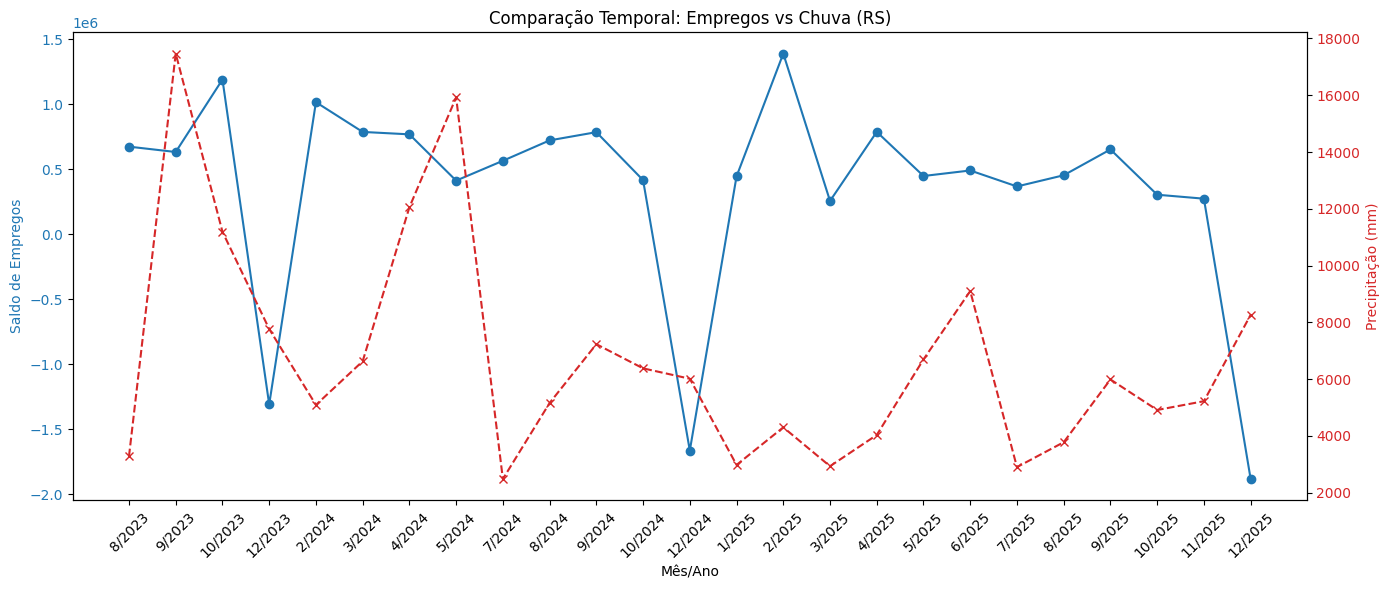

In [ ]:
# CÉLULA 6
if not df_merged.empty:
    df_merged['Data_Ref'] = df_merged['Mes'].astype(str) + '/' + df_merged['Ano'].astype(str)
    
    df_plot = df_merged.groupby(['Ano', 'Mes', 'Data_Ref']).agg({
        'Saldo_Empregos': 'sum',
        'Chuva_Total_Mes': 'mean'
    }).reset_index().sort_values(['Ano', 'Mes'])

    fig, ax1 = plt.subplots(figsize=(14, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Mês/Ano')
    ax1.set_ylabel('Saldo de Empregos', color=color)
    ax1.plot(df_plot['Data_Ref'], df_plot['Saldo_Empregos'], color=color, marker='o', label='Saldo')
    ax1.tick_params(axis='y', labelcolor=color)
    plt.xticks(rotation=45)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Precipitação (mm)', color=color)
    ax2.plot(df_plot['Data_Ref'], df_plot['Chuva_Total_Mes'], color=color, linestyle='--', marker='x', label='Chuva')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Comparação Temporal: Empregos vs Chuva (RS)')
    fig.tight_layout()
    
    plt.savefig(RAIZ / "outputs" / "charts" / "evolucao_temporal_rs.png")
    plt.show()

In [ ]:

# CÉLULA 7
df_agrupado = df_merged.groupby(['Ano', 'Mes'])[['Saldo_Empregos', 'Chuva_Total_Mes']].sum().reset_index()
df_agrupado = df_agrupado.sort_values(['Ano', 'Mes'])


df_agrupado['Saldo_Mes_Seguinte'] = df_agrupado['Saldo_Empregos'].shift(-1)

corr_direta = df_agrupado['Chuva_Total_Mes'].corr(df_agrupado['Saldo_Empregos'])
corr_atrasada = df_agrupado['Chuva_Total_Mes'].corr(df_agrupado['Saldo_Mes_Seguinte'])

print(f"📊 Correlação Direta (Mês Atual): {corr_direta:.4f}")
print(f"🕒 Correlação com Atraso (Impacto no Mês Seguinte): {corr_atrasada:.4f}")

display(df_agrupado[['Ano', 'Mes', 'Chuva_Total_Mes', 'Saldo_Empregos', 'Saldo_Mes_Seguinte']].head(6))

📊 Correlação Direta (Mês Atual): 0.0831
🕒 Correlação com Atraso (Impacto no Mês Seguinte): -0.2182


,Ano,Mes,Chuva_Total_Mes,Saldo_Empregos,Saldo_Mes_Seguinte
0,2023,8,101704.8,674368.0,633164.0
1,2023,9,541477.0,633164.0,1190586.0
2,2023,10,693904.0,1190586.0,-1308294.0
3,2023,12,240783.2,-1308294.0,1016305.0
4,2024,2,157870.6,1016305.0,787595.0
5,2024,3,205523.8,787595.0,768930.0
